In [1]:
import sys
sys.path.append('../')

import numpy as np
from matplotlib import pyplot as plt
from qutip.qip.operations import rz, cz_gate
import cmath
from tqdm import tqdm
from matplotlib.colors import LogNorm
import datetime
import pytz
import scqubits.settings as settings
settings.OVERLAP_THRESHOLD = 0.3
from joblib import Parallel, delayed
import itertools
import scipy.sparse as ssp
from sympy import symbols
import utils_2Q_gate_zp as ut
# ut.set_fig_font() ### Set various sizes in plotting
import pandas as pd
import qutip as qt

## Prepare two zero pi 

In [2]:
args_all = ut.get_operator_two_zeropi()
[n_theta1, n_theta2, n_theta1_dress, n_theta2_dress, n_theta1_truc, n_theta2_truc,
eval_tot, order_sort, H0, trunc_states, eket0, eket1, eket_tot  ] = args_all
truc = len(trunc_states)
state_tot = [qt.basis(truc, i) for i in range(truc)]
W_20_50 = np.abs(ut.transition_frequency(order_sort.index('20') , order_sort.index('50'), eval_tot))
idxs = [order_sort.index(i) for i in trunc_states]

In [3]:
n1_22 = n_theta1_truc[trunc_states.index('22'), trunc_states.index('52')]
n2_22 = n_theta2_truc[trunc_states.index('22'), trunc_states.index('52')]
eta = - n2_22 / n1_22
W_target = W_20_50

### get propagator 

In [4]:
drive_ab = False
[tg, fidelity, fidelity_qt, detune,drive_amp
 ] = [90.0,-3.28742709,-3.38933446,-0.04780261,0.02850925]

r_tg = 1.5
tlist = np.linspace(0, tg, num=int(r_tg*tg))  # total time


drive_term = n_theta1_truc + n_theta2_truc if drive_ab else n_theta2_truc
H_qbt_drive = [H0, [2*np.pi* drive_term, ut.drive_gauss_A] ]

pulse_args = {'drive_amp_A': drive_amp,
            'drive_freq_A': W_target + 2*np.pi*detune,
            'gate_time': tg}
tlist = np.linspace(0, tg, num=int(tg))  # total time
prop = qt.propagator( H=H_qbt_drive,
                        t=tlist,
                        args=pulse_args,)[-1]  # get the propagator at the final time step

state_logi = state_tot[:4]
Uz = ut.remove_global_phase(qt.tensor( rz(ut.dphi(prop, (2,2))),
                                    rz(ut.dphi(prop, (1,1)))))

Uc = qt.Qobj([ [prop.matrix_element(s1, s2) for s1 in state_logi]
        for s2 in state_logi  ])
Uc_reshaped = qt.Qobj(Uc.data, dims=[[2, 2], [2, 2]])
Ucprime = ut.remove_global_phase(Uz * Uc_reshaped)
qt.Qobj(np.round(Ucprime, 2))

Quantum object: dims = [[4], [4]], shape = (4, 4), type = oper, isherm = False
Qobj data =
[[ 1.+0.j    0.+0.j    0.+0.j    0.+0.j  ]
 [ 0.+0.j    1.+0.j    0.+0.j    0.+0.j  ]
 [ 0.+0.j    0.+0.j    1.+0.j    0.+0.j  ]
 [ 0.+0.j    0.+0.j    0.+0.j   -1.+0.01j]]

### get fidelity given params

In [5]:
drive_ab = False
[tg, fidelity, fidelity_qt,
 detuning,drive_amp ] =  [90.0,-3.28742709,-3.38933446,-0.04780261,0.02850925]
# [150, 0, 0, 0.001, 0.005]

r_tg = 50
tlist = np.linspace(0, tg, num=int(r_tg*tg)+1)  # total time
pulse_args = {'drive_amp_A': drive_amp,
            'drive_freq_A': W_target + 2*np.pi*detuning,
            'gate_time': tg}

drive_term = n_theta1_truc + n_theta2_truc if drive_ab else n_theta2_truc
H_qbt_drive = [H0, [2*np.pi* drive_term, ut.drive_gauss_A] ]

args = [H_qbt_drive, W_target, tg, state_tot]
arg_de = detuning, drive_amp
fidelity = ut.get_fidelity_cz(arg_de, *args)
print(fidelity, 1-10**fidelity)

-3.3813142202518582 0.9995843901998459


### CZ_population

2it [00:05,  2.59s/it]
2it [00:03,  1.71s/it]


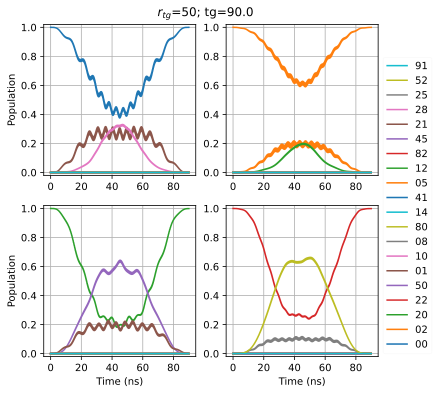

In [6]:
options = qt.Options(store_states=True)
result = {}
logi_state = [0,2]
for idx, state_i in enumerate(logi_state):
    for jdx, state_j in tqdm(enumerate(logi_state)):
        # This simulation is just for viewing the affect of the pulse
        result[idx, jdx] = qt.mesolve(
            H_qbt_drive,
            qt.basis(truc, trunc_states.index( str(state_i) + str(state_j) )),
            tlist,
            e_ops=[state * state.dag() for state in state_tot],
            args=pulse_args,options=options  )
#####################################################################################
##### Drive and Population Visualization #######
fig, ax = plt.subplots(figsize=(6,6), nrows=2, ncols=2)
#ax[0].plot(tlist, drive)
fig.suptitle('$r_{tg}$=%d'%r_tg+ '; tg=%.1f'%tg, y=0.92)
# plt.subplots_adjust(wspace=0.1, hspace=0.1)
order = ['(a)', '(b)','(c)','(d)']
for idx, state_i in enumerate(logi_state):
    for jdx, state_j in enumerate(logi_state):
        for kdx, res in zip(idxs, result[idx,jdx].expect):
            ax[idx][jdx].plot(tlist, res,  label=r"%s" % order_sort[kdx])
        ax[idx][jdx].set_ylim(-0.02,1.02)
        ax[idx][jdx].grid()
        # ax[idx][jdx].set_title('initial state=|'+str(state_i)+str(state_j)+'>')
        # ax[idx][jdx].text(0.05, 0.93, order[2*idx+jdx], transform=ax[idx][jdx].transAxes,  va='top')
    ax[1][idx].set_xlabel('Time (ns)')
    ax[idx][0].set_ylabel('Population')
handles, labels = ax[1][1].get_legend_handles_labels()
ax[1][1].legend(handles[::-1],labels[::-1],
                loc='center left',
                bbox_to_anchor=(1, 1)).get_frame().set_alpha(0.1)

# plt.savefig('../image/zp_cz_full_simulate.png',dpi=150,bbox_inches='tight')

In [ ]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

: 

### CZ_dark_population

In [ ]:
drive_ab = True
args = [H0, n_theta1_truc, n_theta2_truc, eta, W_target, tg, state_tot, drive_ab]
[tg,fidelity,fidelity_qt,
 detuning,drive_amp,d_eta] = [140.0,-4.32373754,-4.41087759,-0.06893879,0.01700783,0.19847014]
# [90.0,-3.50187796,-3.56385284,-0.0429,0.0271,0.234]
arg_de = detuning, drive_amp, d_eta
fidelity = ut.get_fidelity_cz_dark(arg_de, *args)
print(fidelity, 1-10**fidelity)

-4.3237373077182095 0.9999525471072586


2it [00:00,  3.36it/s]
2it [00:00,  2.48it/s]


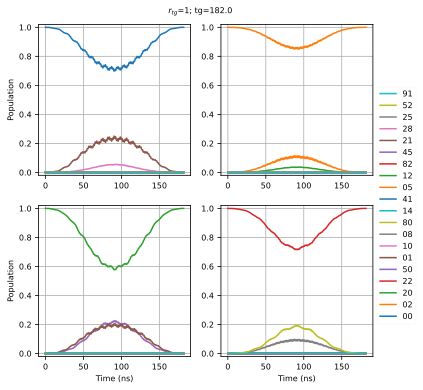

In [ ]:
options = qt.Options(store_states=True)
r_tg = 1.5
tlist = np.linspace(0, tg, num=int(r_tg*tg))  # total time
pulse_args = {'drive_amp_A': drive_amp,
            'drive_freq_A': W_target + 2*np.pi*detuning,
            'gate_time': tg}

drive_term = n_theta2_truc + (eta+d_eta) * n_theta1_truc  if drive_ab else n_theta2_truc
H_qbt_drive = [H0, [2*np.pi* drive_term, ut.drive_gauss_A] ]
result = {}
logi_state = [0,2]
for idx, state_i in enumerate(logi_state):
    for jdx, state_j in tqdm(enumerate(logi_state)):
        # This simulation is just for viewing the affect of the pulse
        result[idx, jdx] = qt.mesolve(
            H_qbt_drive,
            qt.basis(truc, trunc_states.index( str(state_i) + str(state_j) )),
            tlist,
            e_ops=[state * state.dag() for state in state_tot],
            args=pulse_args,options=options  )
#####################################################################################
##### Drive and Population Visualization #######
fig, ax = plt.subplots(figsize=(6,6), nrows=2, ncols=2)
#ax[0].plot(tlist, drive)
fig.suptitle('$r_{tg}$=%d'%r_tg+ '; tg=%.1f'%tg, y=0.92)
# plt.subplots_adjust(wspace=0.1, hspace=0.1)
order = ['(a)', '(b)','(c)','(d)']
for idx, state_i in enumerate(logi_state):
    for jdx, state_j in enumerate(logi_state):
        for kdx, res in zip(idxs, result[idx,jdx].expect):
            ax[idx][jdx].plot(tlist, res,  label=r"%s" % order_sort[kdx])
        ax[idx][jdx].set_ylim(-0.02,1.02)
        ax[idx][jdx].grid()
        # ax[idx][jdx].set_title('initial state=|'+str(state_i)+str(state_j)+'>')
        # ax[idx][jdx].text(0.05, 0.93, order[2*idx+jdx], transform=ax[idx][jdx].transAxes,  va='top')
    ax[1][idx].set_xlabel('Time (ns)')
    ax[idx][0].set_ylabel('Population')
handles, labels = ax[1][1].get_legend_handles_labels()
ax[1][1].legend(handles[::-1],labels[::-1],
                loc='center left',
                bbox_to_anchor=(1, 1)).get_frame().set_alpha(0.1)

# plt.savefig('../image/zp_cz_full_simulate.png',dpi=150,bbox_inches='tight')

In [ ]:
transposed_list = list(zip(*result[1,0].expect))
df = pd.DataFrame(transposed_list, columns=trunc_states)
# df.to_csv('data/cz_dark_population_20.txt', sep=',', index=True, header=True)

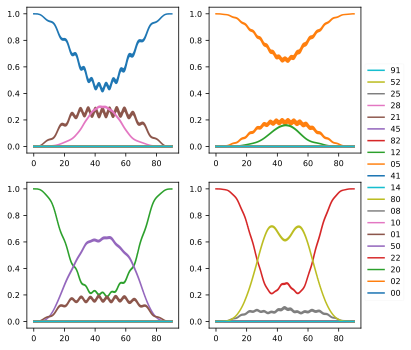

In [ ]:
df_00 = pd.read_csv('data/cz_dark_population_00.txt', index_col=0)
df_02 = pd.read_csv('data/cz_dark_population_02.txt', index_col=0)
df_20 = pd.read_csv('data/cz_dark_population_20.txt', index_col=0)
df_22 = pd.read_csv('data/cz_dark_population_22.txt', index_col=0)
fig, ax = plt.subplots(figsize=(6,5.8), nrows=2, ncols=2)
for kdx, res in enumerate(trunc_states):
    ax[0][0].plot(tlist, df_00[res], label=r"%s" % res)
for kdx, res in enumerate(trunc_states):
    ax[0][1].plot(tlist, df_02[res], label=r"%s" % res)
for kdx, res in enumerate(trunc_states):
    ax[1][0].plot(tlist, df_20[res], label=r"%s" % res)
for kdx, res in enumerate(trunc_states):
    ax[1][1].plot(tlist, df_22[res], label=r"%s" % res)
handles, labels = ax[1][1].get_legend_handles_labels()
ax[1][1].legend(handles[::-1],labels[::-1],
                loc='center left',
                bbox_to_anchor=(1, 1)).get_frame().set_alpha(0.1)

#### cz_fidelity_sensivity

In [ ]:

detune_vec = np.linspace(-0.025, 0.025, 101)
values_grid = list(itertools.product(detuning + detune_vec, [drive_amp], [d_eta]))
fidelity_wd = Parallel(n_jobs=len(detune_vec), verbose=1)(delayed(ut.get_fidelity_cz_dark)(arg_de, *args)
                                            for arg_de in values_grid)

A_vec = np.linspace(-0.025, 0.025, 101)
values_grid = list(itertools.product([detuning], drive_amp+A_vec, [d_eta]))
fidelity_A = Parallel(n_jobs=len(A_vec), verbose=1)(delayed(ut.get_fidelity_cz_dark)(arg_de, *args)
                                            for arg_de in values_grid)

eta_vec = np.linspace(-0.05, 0.05, 101)
values_grid = list(itertools.product([detuning], [drive_amp], d_eta+eta_vec))
fidelity_eta = Parallel(n_jobs=len(eta_vec), verbose=1)(delayed(ut.get_fidelity_cz_dark)(arg_de, *args)
                                            for arg_de in values_grid)

[Parallel(n_jobs=101)]: Using backend LokyBackend with 101 concurrent workers.
[Parallel(n_jobs=101)]: Done   2 out of 101 | elapsed:    1.3s remaining:  1.0min
[Parallel(n_jobs=101)]: Done 101 out of 101 | elapsed:    1.9s finished
[Parallel(n_jobs=101)]: Using backend LokyBackend with 101 concurrent workers.
[Parallel(n_jobs=101)]: Done   2 out of 101 | elapsed:    1.2s remaining:  1.0min
[Parallel(n_jobs=101)]: Done 101 out of 101 | elapsed:    1.9s finished
[Parallel(n_jobs=101)]: Using backend LokyBackend with 101 concurrent workers.
[Parallel(n_jobs=101)]: Done   2 out of 101 | elapsed:    1.3s remaining:  1.0min
[Parallel(n_jobs=101)]: Done 101 out of 101 | elapsed:    2.1s finished


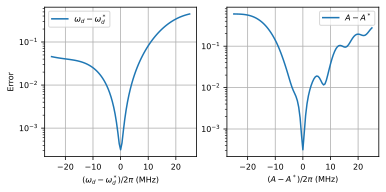

In [ ]:
error_vs_dwd = np.column_stack((np.round(10**3 * detune_vec, 2), np.round(fidelity_wd, 8)))
columns = ['dwd_vec(MHz)',  'error_wd']
df = pd.DataFrame(error_vs_dwd, columns=columns)
# df.to_csv('data/cz_dark_tg90_error_vs_dwd.txt', sep=',', index=True, header=True)

# error_vs_A = np.column_stack((np.round(10**3 * A_vec, 2), np.round(fidelity_A, 8)))
# columns = ['dA_vec(MHz)',  'error_A']
# df = pd.DataFrame(error_vs_A, columns=columns)
# df.to_csv('data/cz_dark_tg90_error_vs_dA.txt', sep=',', index=True, header=True)

# error_vs_eta = np.column_stack((np.round( eta_vec, 2), np.round(fidelity_eta, 8)))
# columns = ['eta_vec',  'error_A']
# df = pd.DataFrame(error_vs_eta, columns=columns)
# df.to_csv('data/cz_dark_tg90_error_vs_eta.txt', sep=',', index=True, header=True)

df_wd = pd.read_csv('data/cz_dark_tg90_error_vs_dwd.txt')
df_dA = pd.read_csv('data/cz_dark_tg90_error_vs_dA.txt')
df_eta = pd.read_csv('data/cz_dark_tg90_error_vs_eta.txt')

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(6,2.7))
ax[0].plot( df_wd['dwd_vec(MHz)'], 10**df_wd['error_wd'], '-', label='$\omega_{d} - \omega_{d}^*$')
ax[0].set_yscale('log')
ax[0].set_xlabel(r'$(\omega_{d} - \omega_{d}^*)/2\pi$ (MHz)')
ax[0].set_ylabel('Error')
ax[0].grid()
ax[0].legend()

ax[1].plot( df_dA['dA_vec(MHz)'], 10**df_dA['error_A'], '-', label='$A - A^*$')
ax[1].set_yscale('log')
ax[1].set_xlabel(r'$(A - A^*)/2\pi$ (MHz)')
ax[1].grid()
ax[1].legend()
# plt.savefig('cnot_fidelity_tg.png', dpi=300, bbox_inches='tight')

#### cz_fidelity_print

In [ ]:
df_cz_dark = pd.read_csv('data/data_cz_n1n2_20_dark.txt')
para = df_cz_dark[['tg','detuning', 'drive_amp', 'd_eta']].to_numpy()
n1_22 = n_theta1_truc[trunc_states.index('22'), trunc_states.index('52')]
n2_22 = n_theta2_truc[trunc_states.index('22'), trunc_states.index('52')]
eta = - n2_22 / n1_22
W_target = np.abs(ut.transition_frequency(order_sort.index('20') , order_sort.index('50'), eval_tot))
args = [H0, n_theta1_truc, n_theta2_truc, eta, W_target, state_tot, drive_ab]
fidelity_w1 = Parallel(n_jobs=80, verbose=1)(delayed(ut.get_fidelity_cz_dark_print)(arg_de, *args)
                                            for arg_de in para)

[Parallel(n_jobs=80)]: Using backend LokyBackend with 80 concurrent workers.
[Parallel(n_jobs=80)]: Done   4 out of  81 | elapsed:    3.9s remaining:  1.3min
[Parallel(n_jobs=80)]: Done  81 out of  81 | elapsed:    6.6s finished


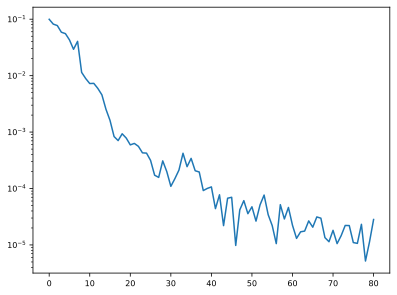

In [ ]:
plt.plot( 10**np.array(fidelity_w1))
plt.yscale('log')

### Jump operators

In [ ]:
gamma_2 =  1
gamma_p2 = 1.1
gamma_3 =  10
gamma_p3 =  11

idxs = [order_sort.index(i) for i in trunc_states]
trunc_dim = eket1.shape[0]
truc = len(trunc_states)
eket_truc = [eket_tot[i] for i in idxs]
eket_truc = np.reshape(eket_truc, (truc, trunc_dim**2))
jump_t1 = np.zeros((truc, truc), dtype=complex)
jump_tphi = np.zeros((truc, truc), dtype=complex)
for i in range(1,10):
    ladder_0i = qt.basis(trunc_dim,0) * qt.basis(trunc_dim,i).dag()
    a_0i_I = qt.tensor(ladder_0i, qt.qeye(trunc_dim))
    a_I_0i = qt.tensor(qt.qeye(trunc_dim), ladder_0i)
    jump_t1_i = (eket_truc @ ( a_0i_I + a_I_0i ).data @ eket_truc.conj().T)

    proj_ii = qt.basis(trunc_dim,i).proj()
    a_ii_I = qt.tensor(proj_ii, qt.qeye(trunc_dim))
    a_I_ii = qt.tensor(qt.qeye(trunc_dim), proj_ii)
    jump_tphi_i = (eket_truc @ ( a_ii_I + a_I_ii ).data @ eket_truc.conj().T)

    if i == 1:
        jump_t1 += np.sqrt(gamma_2)* jump_t1_i
        jump_tphi += np.sqrt(2*gamma_p2) * jump_tphi_i
    else:
        jump_t1 += np.sqrt(gamma_3)* jump_t1_i
        jump_tphi += np.sqrt(2*gamma_p3) * jump_tphi_i
jump_t1 = qt.Qobj(jump_t1)
jump_tphi = qt.Qobj(jump_tphi)

In [ ]:
jump_t1.tidyup(atol=1e-3)

In [ ]:
eket_truc = np.reshape([eket_tot[i] for i in idxs], (truc, eket1.shape[0]**2))
jump_op_t1 = np.zeros((truc, truc), dtype=complex)
jump_op_tphi = np.zeros((truc, truc), dtype=complex)
for state in trunc_states[1:]:
    a0i = eket0[0].conj().T @ eket0[int(state[0])]
    a0i = eket0 @ a0i @ eket0.conj().T

    b0j = eket1[0].conj().T @ eket1[int(state[1])]
    b0j = eket1 @ b0j @ eket1.conj().T

    jump_op_t1 += (eket_truc @ np.kron(a0i, b0j) @ eket_truc.conj().T)

    aii = eket0[int(state[0])].conj().T @ eket0[int(state[0])]
    aii = eket0 @ aii @ eket0.conj().T
    bjj = eket1[int(state[1])].conj().T @ eket1[int(state[1])]
    bjj = eket1 @ bjj @ eket1.conj().T
    eket_truc = np.reshape([eket_tot[i] for i in idxs], (truc, eket1.shape[0]**2))
    jump_op_tphi += (eket_truc @ np.kron(aii, bjj) @ eket_truc.conj().T)

jump_op_t1 = qt.Qobj(jump_op_t1) * np.sqrt(gamma_2)
jump_op_tphi = qt.Qobj(jump_op_tphi) * np.sqrt(2*gamma_p2)

In [ ]:
for i in range(1,10):
    proj_0i = qt.basis(trunc_dim,0) * qt.basis(trunc_dim,i).trans()
    a_0i_I = qt.tensor(proj_0i, qt.qeye(trunc_dim))
    a_I_0i = qt.tensor(qt.qeye(trunc_dim), proj_0i)
    jump_op_t1 += (eket_truc @ (a_0i_I+a_I_0i).data @ eket_truc.conj().T)

In [ ]:
trunc_dim=10
i = 2
jump_op_t1 = np.zeros((truc, truc), dtype=complex)
a0i = qt.basis(trunc_dim,0) * qt.basis(trunc_dim,i).trans()
a0i_I = qt.tensor(a0i, qt.qeye(trunc_dim))
truc = len(trunc_states)

idxs = [order_sort.index(i) for i in trunc_states]
eket_truc_ = [eket_tot[i] for i in idxs]

eket_truc = np.reshape(eket_truc_, (truc, eket1.shape[0]**2))
jump_op_t1 += (eket_truc @ a0i_I.data @ eket_truc.conj().T)

In [ ]:
aaa = eket_truc @ a0i_I.data @ eket_truc.conj().T
qt.Qobj(aaa).tidyup()

In [ ]:
W_20_50 = np.abs(ut.transition_frequency(order_sort.index('20') , order_sort.index('50'), eval_tot))
W_22_52 = np.abs(ut.transition_frequency(order_sort.index('22') , order_sort.index('52'), eval_tot))
W_00_01 = np.abs(ut.transition_frequency(order_sort.index('00') , order_sort.index('01'), eval_tot))
print('W_20_50 = ', W_20_50)
print('W_22_52 = ', W_22_52)
print('W_00_01 = ', W_00_01)

# $n_1$

In [ ]:
pa_n1_20 = np.array([
[0.008072686456606392, 0.04026375737128161] ,
[-0.026219601321467435, 0.03347232582603614] ,
[-0.02202195079756271, 0.033013355739382855] ,
[-0.016756585664457656, 0.032666722845291415] ,
[-0.04344759711916364, 0.04250115530326112] ,
[-0.03417453085487561, 0.02852661965341828] ,
[-0.05592196919398325, 0.027154584089242303] ,
[-0.06927884371923036, 0.02552444134031194] ,
[-0.0782223229229982, 0.023952079273604765] ,
[-0.08492264563797776, 0.02260733739522744] ,
[-0.09043608129578162, 0.021402615114334958] ,
[-0.0948748919345315, 0.02040860805971144] ,
[-0.06439548436267327, 0.01791412478285352] ,
[-0.051329319904350725, 0.016544314109077654] ,
[-0.07479113712020069, 0.016622117311335602] ,
[-0.06240366099366179, 0.015627679870857267] ,
[-0.07482559632905487, 0.015383632557276844] ,
[-0.07817427813765594, 0.014922812201150465] ,
[-0.0816530876863822, 0.014506148557486623] ,
[-0.07799399018212241, 0.013996446502301335] ,
[-0.10438070431150062, 0.01433503600913491] , ])
wd_n1_20 = W_20_50 + 2*np.pi* pa_n1_20[:,0]
wd_n1_20

In [ ]:
tg_vec = np.linspace(40, 200, num=21)
fig, ax = plt.subplots(figsize=(8,1.5))
plt.plot(tg_vec, wd_n1_20, '.')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title('$\omega_d^{n_1-00} - \omega_d^{n_1-20}$')
plt.grid()

In [ ]:
pa_n1_00 = np.array([
[0.09998808220970042, 0.03389647651371554] ,
[0.0999984183445914, 0.03334010208960135] ,
[0.09997059222517883, 0.03279977063159997] ,
[0.09999979127031018, 0.03240779521344887] ,
[0.09069326060862769, 0.04249471582468528] ,
[0.09999883376243134, 0.028511124810695107] ,
[0.07852650155524495, 0.02715111899031597] ,
[0.06520853187760449, 0.025526509160756373] ,
[0.05635106791185157, 0.023967894419161053] ,
[0.04952288298843699, 0.022599052185279273] ,
[0.04407690405035916, 0.0214162618751392] ,
[0.03963968945578836, 0.02040976507375857] ,
[0.07013262402538958, 0.017915752743077988] ,
[0.08315083843208453, 0.016543318108878817] ,
[0.05968069601166326, 0.01662038788855584] ,
[0.07208559720557661, 0.015629110241698066] ,
[0.05964304998313631, 0.015384156071309996] ,
[0.05629629891946006, 0.014923140160711432] ,
[0.05286917059620126, 0.014508309607604242] ,
[0.05651959921673, 0.013995538320386691] ,
[0.05319666279212992, 0.013654384111454164] ,])
wd_n1_00 = W_00_01 + 2*np.pi* pa_n1_00[:,0]
wd_n1_00

In [ ]:
tg_vec = np.linspace(40, 200, num=21)
fig, ax = plt.subplots(figsize=(8,1.5))
plt.plot(tg_vec, wd_n1_00, '.')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title('$\omega_d^{n_1-00} - \omega_d^{n_1-20}$')
plt.grid()

In [ ]:
wd_n1_00 - wd_n1_20

In [ ]:
tg_vec = np.linspace(40, 200, num=21)
fig, ax = plt.subplots(figsize=(8,1.5))
plt.plot(tg_vec, wd_n1_00 - wd_n1_20, '.')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title('$\omega_d^{n_1-00} - \omega_d^{n_1-20}$')
plt.grid()

# $n_2$

In [ ]:
pa_n2_22 = np.array([
[-0.12543802569960816, 0.0417916249940949] ,
[-0.11217803745503305, 0.04035183812339457] ,
[-0.11344293487232537, 0.03890386553456274] ,
[-0.090211249885337, 0.033132072771376725] ,
[-0.07533424625136681, 0.03194918518996296] ,
[-0.049438847578870106, 0.03244666627228647] ,
[-0.03946693548577948, 0.029848904264211502] ,
[-0.032237993210102935, 0.02833364697438628] ,
[-0.030966964969908684, 0.023299092937162036] ,
[-0.02768011827803043, 0.021835308173616525] ,
[-0.02464472841898352, 0.02074834657263286] ,
[-0.021803591735934012, 0.019882448116312335] ,
[-0.05167485874463183, 0.017164989142259113] ,
])
wd_n2_22 = W_22_52 + 2*np.pi* pa_n2_22[:,0]
wd_n2_22

In [ ]:
tg_vec = np.linspace(40, 200, num=21)
fig, ax = plt.subplots(figsize=(8,1.5))
plt.plot(tg_vec[:13], wd_n2_22, '.')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title('$\omega_d$')
plt.grid()

In [ ]:
pa_n2_20 = np.array([
[-0.13489599, 0.04179519, 40.0, -0.81624313, -0.907084508] ,
[-0.12181585, 0.04033307, 48.0, -1.19868667, -1.25989732] ,
[-0.12313573, 0.03890629, 56.0, -1.75946055, -1.84931348] ,
[-0.0999998, 0.03313089, 64.0, -2.02348833, -2.11675684] ,
[-0.08518001, 0.03195758, 72.0, -2.32853766, -2.40378253] ,
[-0.0592095, 0.03243396, 80.0, -2.77269572, -2.85114121] ,
[-0.04928258, 0.02983801, 88.0, -2.87563305, -2.96970408] ,
[-0.04204181, 0.02832025, 96.0, -3.17013305, -3.27095058] ,
[-0.0388998, 0.03360252, 104.0, -3.33643771, -3.41646289] ,
[-0.03302637, 0.03087338, 112.0, -3.96625603, -4.04182622] ,
[-0.03441918, 0.02076661, 120.0, -3.656008, -3.77688879] ,
[-0.03160199, 0.01988816, 128.0, -4.0020057, -4.05923737] ,
# [-0.06150659, 0.01716301, 136.0, -3.75665887, -3.84597613] ,
[0.01072869, 0.01027827, 136.0, -4.70101245, None] ,
[-0.07902074, 0.01669434, 144.0, -4.1266732, -4.2136726] ,
[-0.09328667, 0.01585009, 152.0, -4.9369254, -4.98919321] ,
[-0.03546228, 0.01548912, 160.0, -4.45320218, -4.50990195] ,
[-0.06497353, 0.01494088, 168.0, -4.37817473, -4.4601287] ,
[-0.06167765, 0.01445689, 176.0, -4.24686447, -4.33405505] ,
[-0.05889779, 0.01401448, 184.0, -4.42871367, -4.50736131] ,
[-0.05619229, 0.01360428, 192.0, -4.41433082, -4.48947091] ,
[-0.06017003, 0.01330778, 200.0, -4.39312433, -4.46197193] ,
])
wd_n2_20 = W_20_50 + 2*np.pi* pa_n2_20[:,0]
wd_n2_20

In [ ]:
tg_vec = np.linspace(40, 200, num=21)
fig, ax = plt.subplots(figsize=(8,1.5))
plt.plot(tg_vec, wd_n2_20, '.')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title('$\omega_d$')
plt.grid()

In [ ]:
tg_vec = np.linspace(40, 200, num=21)
fig, ax = plt.subplots(figsize=(8,1.5))
plt.plot(tg_vec[:13], wd_n2_22 - wd_n2_20[:13], '.')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title('$\omega_d^{n_1-00} - \omega_d^{n_1-20}$')
plt.grid()

In [ ]:
=

In [ ]:
n1_22 = n_theta1_truc[trunc_states.index('22'), trunc_states.index('52')]
n2_22 = n_theta2_truc[trunc_states.index('22'), trunc_states.index('52')]
n1_20 = n_theta1_truc[trunc_states.index('20'), trunc_states.index('50')]
n2_20 = n_theta2_truc[trunc_states.index('20'), trunc_states.index('50')]
print(n1_22, n2_22, n1_20, n2_20)

eta = n1_22/n2_22
A_20 = n1_20 - eta* n2_20
print('eta = ', eta)
print('A_20 = ', A_20)